### HW 7 

0) Package Loadings

In [1]:
#%pip install scikit-learn-intelex

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import time
import pandas as pd
from sklearnex import patch_sklearn
patch_sklearn()
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score,GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


1) Loading the data and performing preprocessing steps

In [ ]:
data = pd.read_csv('HW07_data_s.csv')
X = data.drop('Y', axis=1)
y = data['Y']
print(X.shape)
#print(y.value_counts())

# Y values are heavily imbalanced, thus will need to strafiy the data when splitting to ensure that the distribution of classes is maintained in both the training and testing sets.
# Will apply stratification to the train_test_split function to ensure that the class distribution is preserved in both the training and testing sets.


X_dev, X_test, y_dev, y_test = train_test_split(X, y,stratify=y, test_size=0.30, random_state=42)
#scaler = StandardScaler()
#_dev_scaled = scaler.fit_transform(X_dev)
#X_test_scaled = scaler.transform(X_test)

## Realized trees dont need to be scaled and that scaling can actually hurt the performance of tree-based models, so I will not be applying scaling to the data for the decision tree and random forest models.
print(y_dev.value_counts())
print(y_test.value_counts())
#print(X_dev_scaled.shape)

(284807, 30)
Y
0    199020
1       344
Name: count, dtype: int64
Y
0    85295
1      148
Name: count, dtype: int64


In [4]:
### Declaring the stratified k-fold cross validation strategy to be used for all models
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

### Decision Tree Classifier.
The process in this section is to deal with the heavily imbalanced dataset that is shown by this development set
1) When fitting this model onto the development set we will balance class_weight since of the high '0' class to '1' class
2) We will CV the Decision Tree under a 10-fold StratifiedKFold to analyze F1_macro performance.
3) Once we CV and compare scores we will then grid search optimal hyper params and train the best model for downstream analysis

In [5]:
#Defining the baseline decision tree
tree = DecisionTreeClassifier(random_state=42)


score = cross_val_score(tree, X_dev, y_dev, cv=kfold, scoring='f1_macro', n_jobs=-1).mean()
print("Baseline CV F1 score:", score)


Baseline CV F1 score: 0.8686723600091888


In [6]:
#Defining the tree
tree2 = DecisionTreeClassifier(random_state=42,class_weight='balanced')

score = cross_val_score(tree2, X_dev, y_dev, cv=kfold, scoring='f1_macro', n_jobs=-1).mean()
print("Balanced CV F1 score:", score)



Balanced CV F1 score: 0.8564071833309581


In [7]:
tree = DecisionTreeClassifier(random_state=42)
param_grid = {
  'max_depth': [3, 5, 10, None],
  'min_samples_split': [2, 5, 10],
  'min_samples_leaf': [1, 5, 10]
}
# Run GridSearchCV to find the best parameters based on f1 score as it is a better average metric for datasets

grid = GridSearchCV(tree, param_grid, cv=kfold, scoring='f1_macro', n_jobs=-1)
grid.fit(X_dev, y_dev)

best_params_dt = grid.best_params_
print(f"Best Parameters: {best_params_dt}")


Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


Time taken to fit the tree: 2.3311 seconds


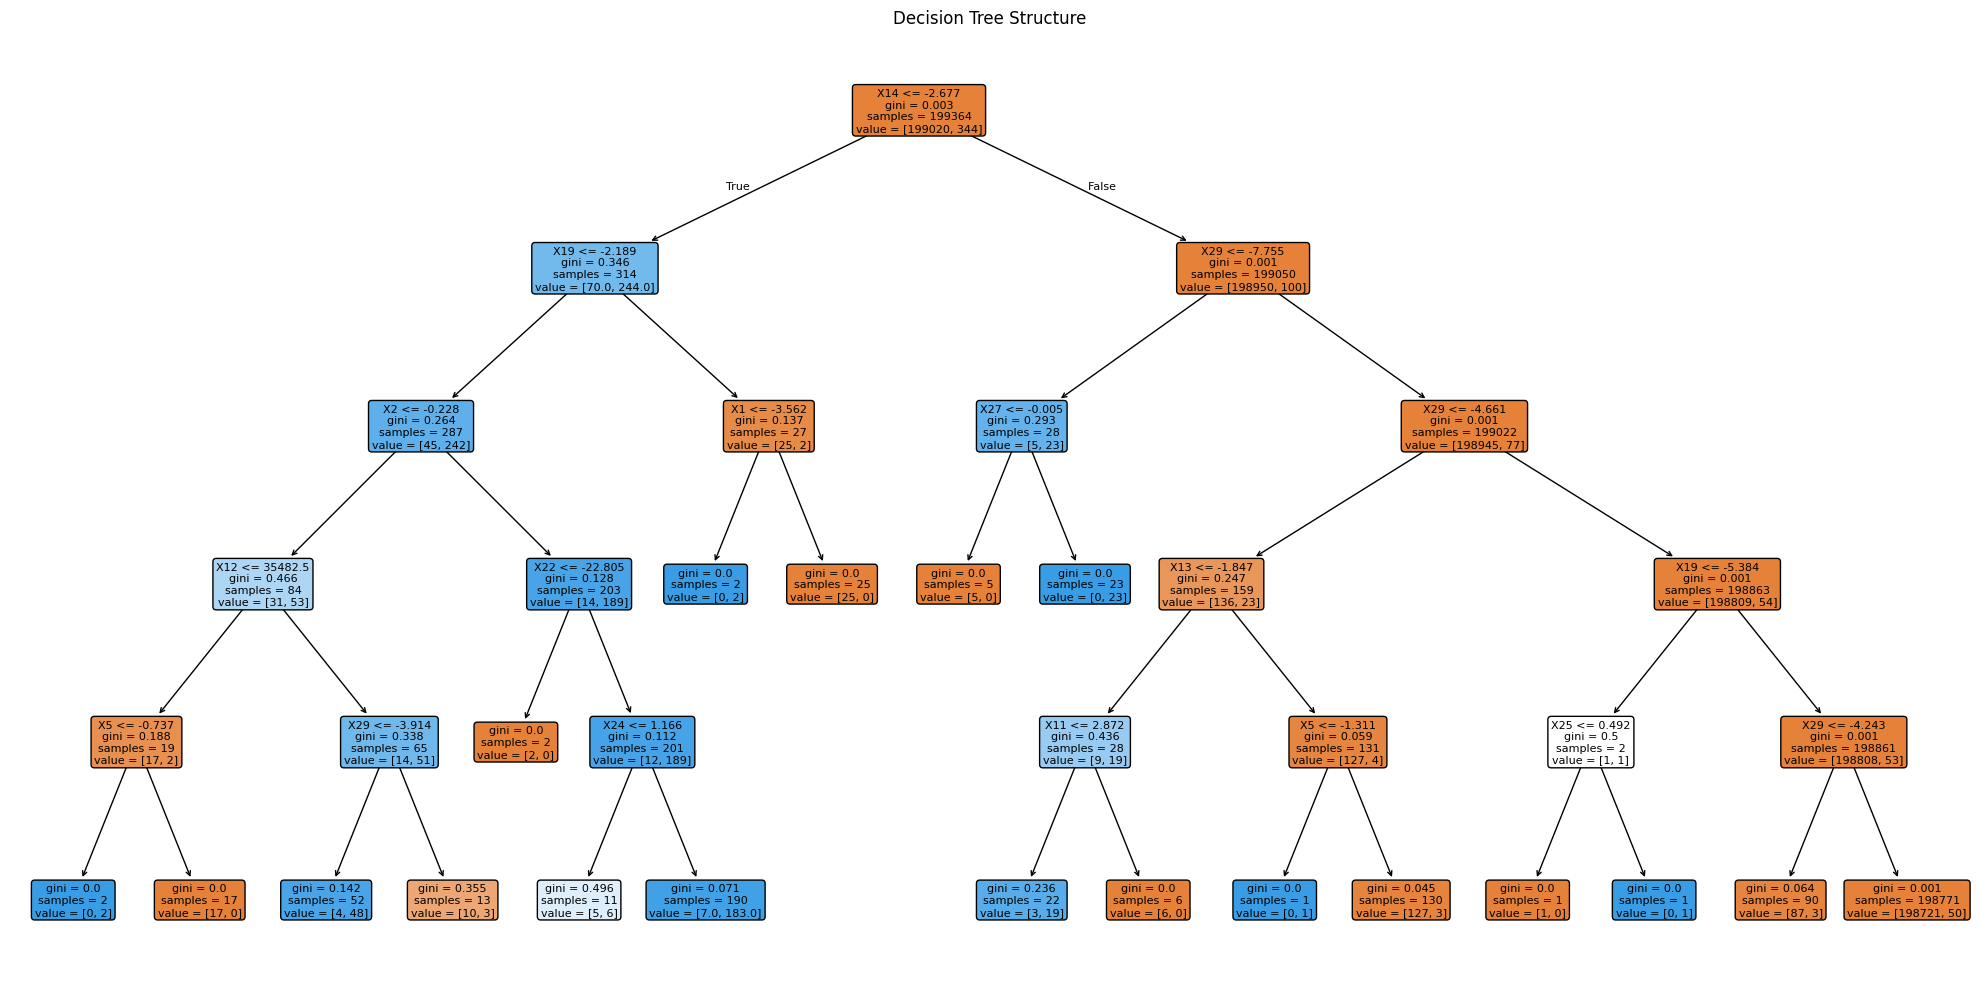

In [8]:
# Visualize best tree structure

dt_best = DecisionTreeClassifier(random_state=42, **best_params_dt)
start_time = time.time() 
dt_best.fit(X_dev, y_dev)
end_time = time.time()
print(f"Time taken to fit the tree: {end_time - start_time:.4f} seconds")
plt.figure(figsize=(20, 10))
plot_tree(dt_best, filled=True, feature_names=X_dev.columns,  rounded=True, fontsize=8)
plt.title("Decision Tree Structure")
plt.tight_layout()
plt.show()

### Random Forest Classifier
1) Compare the class weights: None, balanced, and balanced_subsample
2) Optimize Hyper Parameters
3) Train best model for down stream analysis

In [9]:
#Defining the tree
treeRf1 = RandomForestClassifier(random_state=42,class_weight=None,n_jobs=-1)

score = cross_val_score(treeRf1, X_dev, y_dev, cv=kfold, scoring='f1_macro', n_jobs=-1).mean()
print("Baseline RFC CV F1 score:", score)

Baseline RFC CV F1 score: 0.9255359249847338


In [10]:
#Defining the tree
treeRf2 = RandomForestClassifier(random_state=42,class_weight='balanced',n_jobs=-1)

score = cross_val_score(treeRf2, X_dev, y_dev, cv=kfold, scoring='f1_macro', n_jobs=-1).mean()
print("Balanced RFC CV F1 score:", score)

Balanced RFC CV F1 score: 0.5640120079175408


In [11]:
#Defining the tree
treeRf3 = RandomForestClassifier(random_state=42,class_weight='balanced_subsample',n_jobs=-1)

score = cross_val_score(treeRf3, X_dev, y_dev, cv=kfold, scoring='f1_macro', n_jobs=-1).mean()
print("Balanced_subsample RFC CV F1 score:", score)

Balanced_subsample RFC CV F1 score: 0.9226355301128594


Comparing these scores we see for all three on f1_macro scoring the Baseline RFC performs just slightly better than the balanced_subsample class weight model. Leading to the baseline RFC to perform slightly better on minority class

In [12]:
### Optimizing baseline RFC using GridSearchCV
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid = {
  'n_estimators': [100, 200],
  'max_depth': [5, 10, None],
  'max_features': ['sqrt', 'log2']
}
# Run GridSearchCV to find the best parameters based on f1 score as it is a better average metric for datasets

grid = GridSearchCV(rf, param_grid, cv=kfold, scoring='f1_macro', n_jobs=-1)
grid.fit(X_dev, y_dev)

best_params_rf = grid.best_params_
print(f"Best Parameters: {best_params_rf}")

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}


In [13]:
rf_best = RandomForestClassifier(random_state=42, n_jobs=-1, **best_params_rf)
start_time = time.time() 
rf_best.fit(X_dev, y_dev)
end_time = time.time()
print(f"Time taken to fit the tree: {end_time - start_time:.4f} seconds")

Time taken to fit the tree: 1.0419 seconds


### Gradient Boosting Classifier:
1) Identify Cross Validation score
2) Then optimize it's hyper params to see if there is any improvement to be made
3) Train model for down stream use in analysis

In [14]:
#Defining the tree
treeGb = GradientBoostingClassifier(random_state=42)

score = cross_val_score(treeGb, X_dev, y_dev, cv=kfold, scoring='f1_macro', n_jobs=-1).mean()
print("Baseline GBC CV F1 score:", score)

Baseline GBC CV F1 score: 0.7600388771781132


In [15]:
gb = GradientBoostingClassifier(random_state=42)
param_grid = {
  'n_estimators': [100, 200],
  'learning_rate': [0.01, 0.1],
  'max_depth': [3, 5]
}
# Run GridSearchCV to find the best parameters based on f1 score as it is a better average metric for datasets

grid = GridSearchCV(gb, param_grid, cv=kfold, scoring='f1_macro', n_jobs=-1)
grid.fit(X_dev, y_dev)

best_params_gb = grid.best_params_
print(f"Best Parameters: {best_params_gb}")

Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}


In [16]:
gb_best = GradientBoostingClassifier(random_state=42, **best_params_gb)
start_time = time.time()
gb_best.fit(X_dev, y_dev)
end_time = time.time()
print(f"Time taken to fit the tree: {end_time - start_time:.4f} seconds")

Time taken to fit the tree: 435.6525 seconds


In [17]:
results = []

for model in [dt_best, rf_best, gb_best]:
    model_name = model.__class__.__name__
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Macro)": precision_score(y_test, y_pred, average='macro'),
        "Recall (Macro)": recall_score(y_test, y_pred, average='macro'),
        "F1 Score (Macro)": f1_score(y_test, y_pred, average='macro'),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Pretty display
print(results_df.to_string(index=False))


                     Model  Accuracy  Precision (Macro)  Recall (Macro)  F1 Score (Macro)  ROC-AUC
    DecisionTreeClassifier  0.999391           0.949766        0.864795          0.902833 0.861360
    RandomForestClassifier  0.999497           0.986252        0.864847          0.916862 0.936201
GradientBoostingClassifier  0.999427           0.976806        0.851322          0.904526 0.948279



=== DecisionTreeClassifier ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.90      0.73      0.81       148

    accuracy                           1.00     85443
   macro avg       0.95      0.86      0.90     85443
weighted avg       1.00      1.00      1.00     85443


=== RandomForestClassifier ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.97      0.73      0.83       148

    accuracy                           1.00     85443
   macro avg       0.99      0.86      0.92     85443
weighted avg       1.00      1.00      1.00     85443


=== GradientBoostingClassifier ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.95      0.70      0.81       148

    accuracy                           1.00     85443
   macro avg       0.98     

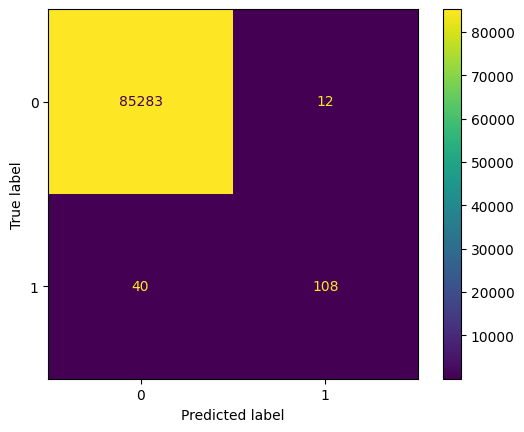

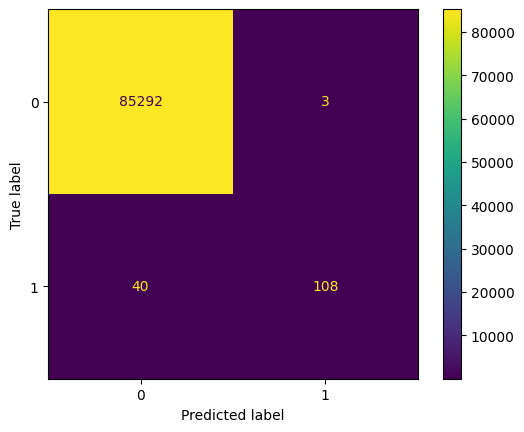

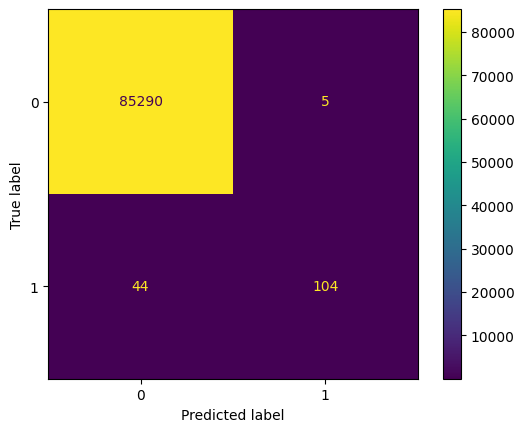

In [20]:
for model in [dt_best, rf_best, gb_best]:
    print(f"\n=== {model.__class__.__name__} ===")
    print(classification_report(y_test, model.predict(X_test)))
    ConfusionMatrixDisplay.from_predictions(y_test, model.predict(X_test))